# Analyzing Dietary Habits Using Unsupervised Learning Techniques
**ARTI 308 – Machine Learning | Group 4**

| # | Name | ID | Role |
|---|------|----|------|
| 1 | Wesam Jaber Almalki | 2240005660 | Leader |
| 2 | Fahad Nawar Alotaibi | 2240002024 | Member |
| 3 | Fawaz Alshahrani | 2240005571 | Member |
| 4 | Faris Alshahrani | 2240005572 | Member |
| 5 | Ahmed Albouainain | 2240006128 | Member |
| 6 | Anas Hamzi | 2240003869 | Member |

---
**Objective:** Apply unsupervised learning (K-Means, Hierarchical Clustering) with dimensionality reduction (PCA, t-SNE) to discover hidden dietary behavior patterns without relying on predefined labels.

## Imports

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

---
## 1. Load Data

In [60]:
df = pd.read_csv("dataset/diet_recommendations_dataset (best).csv")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")
print(f"\nData types:\n{df.dtypes.value_counts()}")

DATASET OVERVIEW
Shape: 1000 rows × 15 columns

Columns:
['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'Disease_Type', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Preferred_Cuisine', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score']

Missing values:
0 total

Data types:
float64    7
str        4
int64      4
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis
Inspect distributions of categorical and numerical features before modelling.


EXPLORATORY DATA ANALYSIS

Numerical summary:
           Age  Weight_kg  Height_cm      BMI  Daily_Caloric_Intake  \
count  1000.00    1000.00    1000.00  1000.00               1000.00   
mean     49.86      84.60     174.82    28.19               2475.06   
std      18.11      20.09      14.33     8.04                565.02   
min      18.00      50.00     150.00    13.00               1500.00   
25%      35.00      66.60     162.00    22.08               1984.75   
50%      50.00      85.20     175.00    27.45               2470.50   
75%      66.00     102.00     187.00    33.42               2937.25   
max      79.00     119.70     199.00    52.40               3498.00   

       Cholesterol_mg/dL  Blood_Pressure_mmHg  Glucose_mg/dL  \
count            1000.00              1000.00        1000.00   
mean              226.10               149.26         118.69   
std                13.51                13.06          25.39   
min               200.30               125.00          85

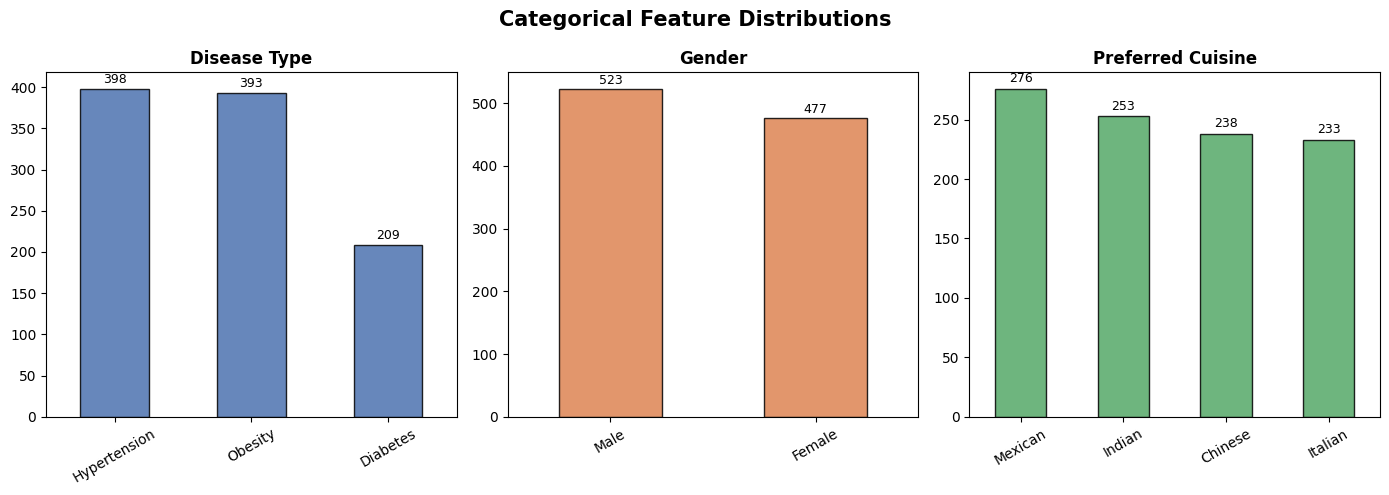

In [61]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print("\nNumerical summary:")
print(df.describe().round(2))

print("\nCategorical distributions:")
for col in ["Gender", "Disease_Type", "Preferred_Cuisine"]:
    print(f"\n{col}:\n{df[col].value_counts()}")

# Plot categorical distributions (1×3 grid)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold")
cats   = ["Disease_Type", "Gender", "Preferred_Cuisine"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
for ax, col, color in zip(axes, cats, colors):
    counts = df[col].value_counts()
    counts.index = counts.index.astype(str)
    counts.plot(kind="bar", ax=ax, color=color, edgecolor="black", alpha=0.85)
    ax.set_title(col.replace("_", " "), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 3, int(bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("eda_categorical.png", dpi=150)
plt.show()

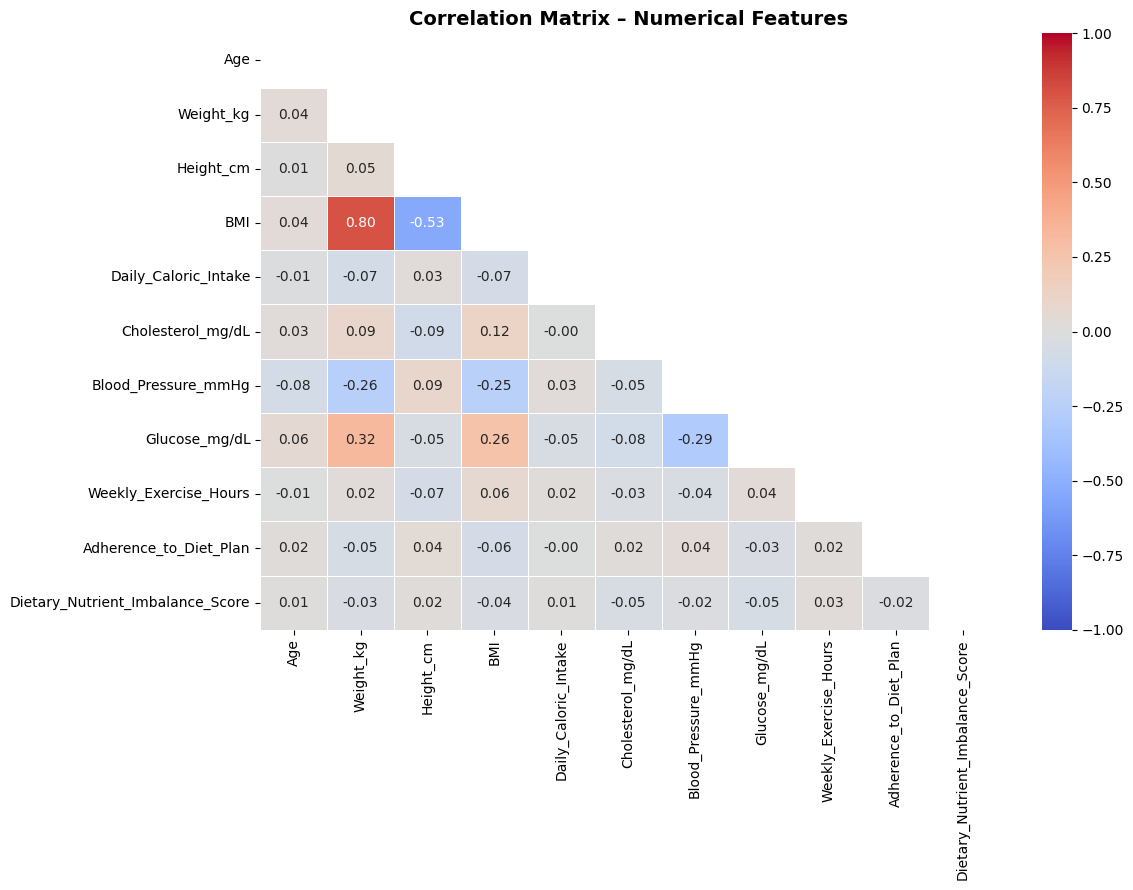

In [48]:
# Correlation heatmap — all numerical columns in the dataset
num_cols = ["Age", "Weight_kg", "Height_cm", "BMI", "Daily_Caloric_Intake",
            "Cholesterol_mg/dL", "Blood_Pressure_mmHg", "Glucose_mg/dL",
            "Weekly_Exercise_Hours", "Adherence_to_Diet_Plan",
            "Dietary_Nutrient_Imbalance_Score"]

plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix – Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150)
plt.show()

---
## 3. Preprocessing & Feature Engineering
- `Patient_ID` dropped — identifier with no analytical value
- `Disease_Type` excluded from clustering, saved for post-hoc validation only
- `Physical_Activity_Level` was dropped from the dataset before this analysis
- `Gender` and `Preferred_Cuisine` excluded — no medical link to the three disease groups; including them adds noise
- Two redundant numerical features removed based on correlation matrix:
  - `Weight_kg` (r = 0.80 with BMI — BMI is the medically preferred variable)
  - `Height_cm` (near-zero correlation with all other features)
- All 9 remaining numerical features standardized with `StandardScaler`

In [62]:
print("\n" + "=" * 60)
print("PREPROCESSING")
print("=" * 60)

# Patient_ID dropped — identifier
# Disease_Type saved for post-hoc validation only
# Gender & Preferred_Cuisine excluded — no medical link to disease groups
labels_disease = df["Disease_Type"].copy()

# 9 clinically relevant numerical features
# Removed: Weight_kg (r=0.80 with BMI), Height_cm (near-zero corr with everything)
numerical = [
    "Age", "BMI", "Daily_Caloric_Intake",
    "Cholesterol_mg/dL", "Blood_Pressure_mmHg", "Glucose_mg/dL",
    "Weekly_Exercise_Hours", "Adherence_to_Diet_Plan",
    "Dietary_Nutrient_Imbalance_Score"
]

df_encoded = df[numerical].copy()

print(f"Features ({len(numerical)}): {numerical}")
print(f"Feature matrix shape: {df_encoded.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
print("Standardization complete.")


PREPROCESSING
Features (9): ['Age', 'BMI', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score']
Feature matrix shape: (1000, 9)
Standardization complete.


---
## 4. Dimensionality Reduction
PCA is used to determine how many components explain 95% of variance, then both PCA and t-SNE reduce to 2D for cluster visualization.


DIMENSIONALITY REDUCTION
Components needed for 95% variance: 9


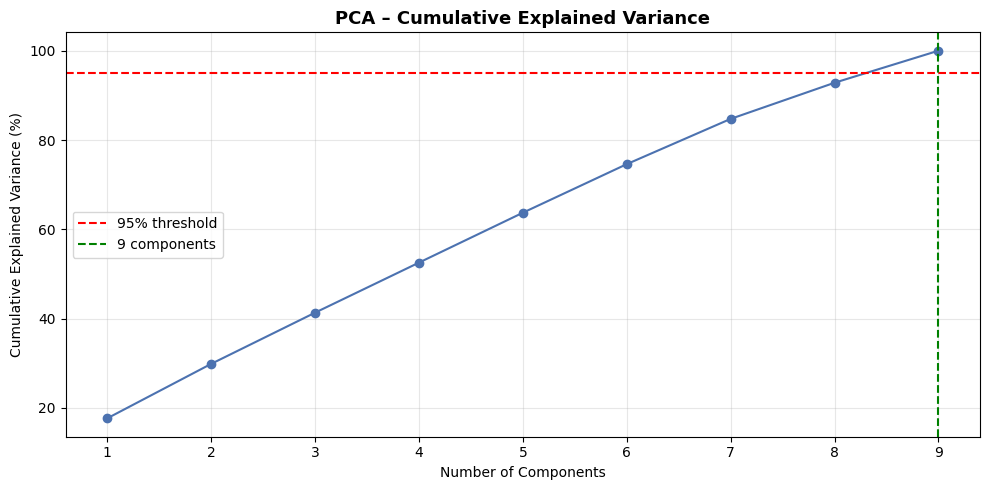

PCA 2D variance explained: 29.9%
Running t-SNE (this may take a moment)...
t-SNE complete.


In [63]:
print("\n" + "=" * 60)
print("DIMENSIONALITY REDUCTION")
print("=" * 60)

# PCA – explained variance
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", color="#4C72B0")
plt.axhline(95, color="red", linestyle="--", label="95% threshold")
plt.axvline(n_components_95, color="green", linestyle="--",
            label=f"{n_components_95} components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA \u2013 Cumulative Explained Variance", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"PCA 2D variance explained: {pca_2d.explained_variance_ratio_.sum():.1%}")

# t-SNE 2D
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE complete.")

---
## 5. K-Means Clustering – Finding Optimal K
Three metrics are used to identify the best number of clusters:
- **Elbow Method** (Inertia / WSS)
- **Silhouette Score** (higher = better)
- **Davies-Bouldin Index** (lower = better)


K-MEANS – FINDING OPTIMAL K
  K=2  Inertia=7820  Silhouette=0.1251  DBI=2.5097
  K=3  Inertia=7286  Silhouette=0.1071  DBI=2.5714
  K=4  Inertia=6826  Silhouette=0.1057  DBI=2.3903
  K=5  Inertia=6495  Silhouette=0.1003  DBI=2.4645
  K=6  Inertia=6212  Silhouette=0.1004  DBI=2.2563
  K=7  Inertia=5992  Silhouette=0.0995  DBI=2.0173
  K=8  Inertia=5762  Silhouette=0.1001  DBI=2.0885
  K=9  Inertia=5567  Silhouette=0.1042  DBI=1.9868
  K=10  Inertia=5418  Silhouette=0.1037  DBI=1.9625


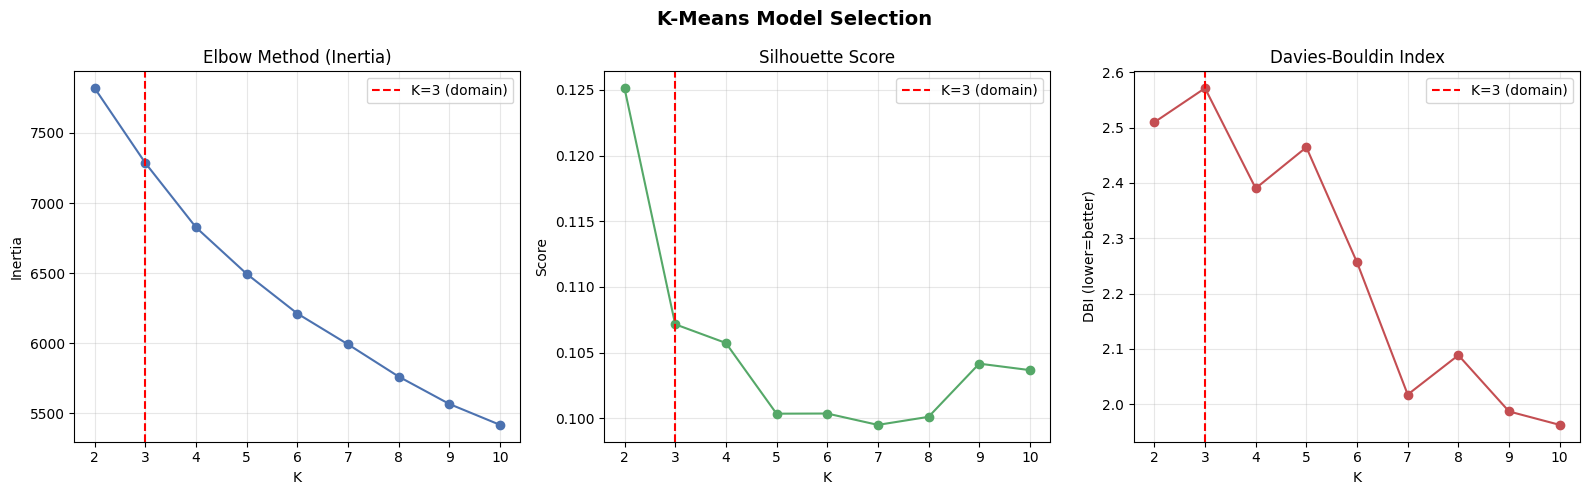


Selected K = 3  (domain knowledge: Hypertension / Obesity / Diabetes)


In [64]:
print("\n" + "=" * 60)
print("K-MEANS – FINDING OPTIMAL K")
print("=" * 60)

inertias, silhouettes, dbi_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  K={k}  Inertia={km.inertia_:.0f}  "
          f"Silhouette={silhouettes[-1]:.4f}  DBI={dbi_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("K-Means Model Selection", fontsize=14, fontweight="bold")

axes[0].plot(K_range, inertias, marker="o", color="#4C72B0")
axes[0].axvline(3, color="red", linestyle="--", label="K=3 (domain)")
axes[0].set_title("Elbow Method (Inertia)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, marker="o", color="#55A868")
axes[1].axvline(3, color="red", linestyle="--", label="K=3 (domain)")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(K_range, dbi_scores, marker="o", color="#C44E52")
axes[2].axvline(3, color="red", linestyle="--", label="K=3 (domain)")
axes[2].set_title("Davies-Bouldin Index")
axes[2].set_xlabel("K"); axes[2].set_ylabel("DBI (lower=better)")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("kmeans_selection.png", dpi=150)
plt.show()

# Domain knowledge override: dataset has 3 known disease groups
best_k = 3
print(f"\nSelected K = {best_k}  (domain knowledge: Hypertension / Obesity / Diabetes)")

---
## 6. Final K-Means Model
Train the final K-Means model using the optimal K and visualize clusters via PCA and t-SNE projections.


FINAL K-MEANS MODEL  (K=3)
Silhouette Score : 0.1071
Davies-Bouldin   : 2.5714
Inertia          : 7285.74
Cluster sizes    : {np.int32(0): np.int64(396), np.int32(1): np.int64(382), np.int32(2): np.int64(222)}


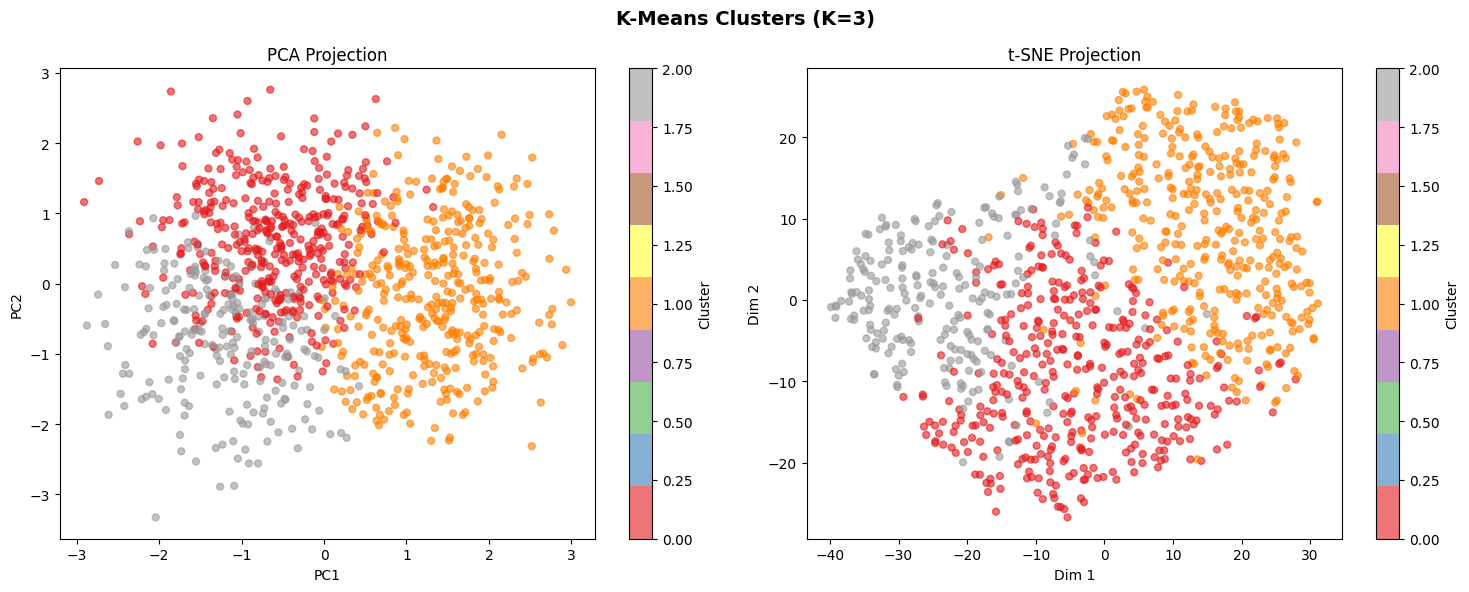

In [65]:
print("\n" + "=" * 60)
print(f"FINAL K-MEANS MODEL  (K={best_k})")
print("=" * 60)

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, km_labels)
dbi = davies_bouldin_score(X_scaled, km_labels)
print(f"Silhouette Score : {sil:.4f}")
print(f"Davies-Bouldin   : {dbi:.4f}")
print(f"Inertia          : {km_final.inertia_:.2f}")
print(f"Cluster sizes    : {dict(zip(*np.unique(km_labels, return_counts=True)))}")

# Visualize clusters with categorical colormap for clear separation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"K-Means Clusters (K={best_k})", fontsize=14, fontweight="bold")

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=km_labels, cmap="Set1", alpha=0.6, s=25)
axes[0].set_title("PCA Projection"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=km_labels, cmap="Set1", alpha=0.6, s=25)
axes[1].set_title("t-SNE Projection"); axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")
plt.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()

---
## 7. Hierarchical Clustering
Ward linkage dendrogram on a 200-sample subset, then Agglomerative Clustering fitted on the full dataset using the same K.


HIERARCHICAL CLUSTERING


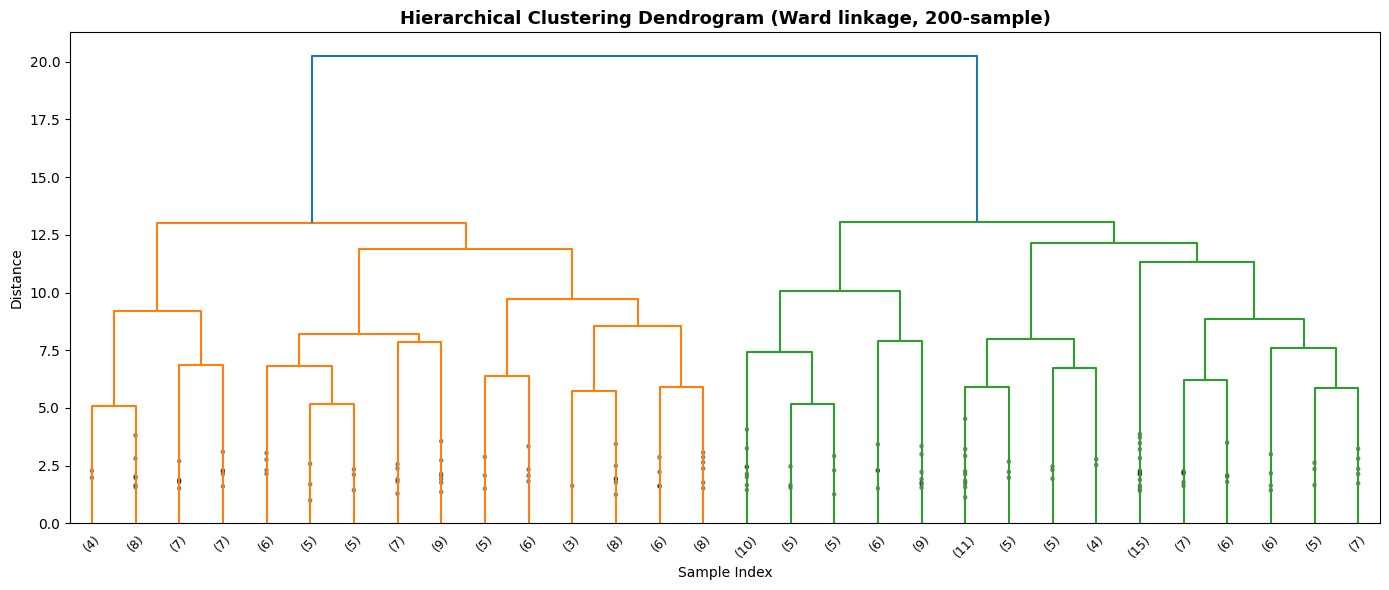

Silhouette Score : 0.0984
Davies-Bouldin   : 2.6234
Cluster sizes    : {np.int64(0): np.int64(421), np.int64(1): np.int64(447), np.int64(2): np.int64(132)}


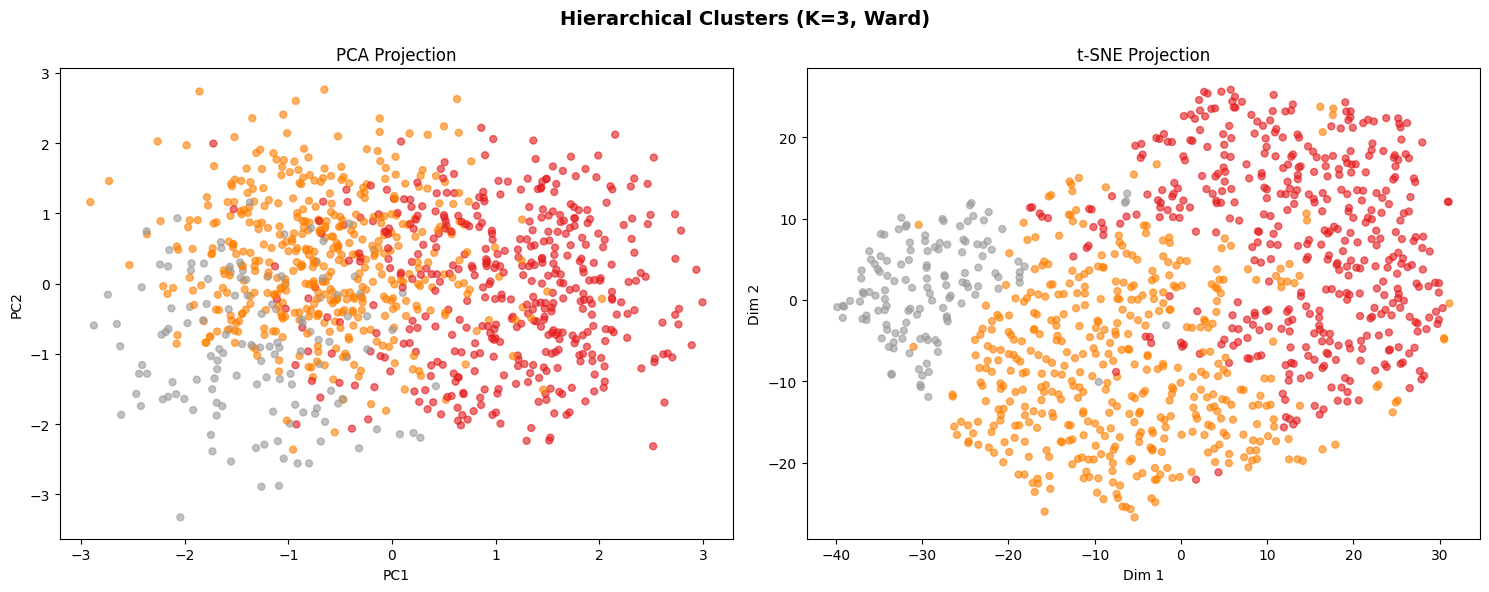

In [66]:
print("\n" + "=" * 60)
print("HIERARCHICAL CLUSTERING")
print("=" * 60)

# Dendrogram (sample 200 for readability)
sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=45,
           leaf_font_size=9, show_contracted=True,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, 200-sample)",
          fontsize=13, fontweight="bold")
plt.xlabel("Sample Index"); plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("hierarchical_dendrogram.png", dpi=150)
plt.show()

# Agglomerative with K=3 (same as K-Means for comparison)
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, agg_labels)
dbi_agg = davies_bouldin_score(X_scaled, agg_labels)
print(f"Silhouette Score : {sil_agg:.4f}")
print(f"Davies-Bouldin   : {dbi_agg:.4f}")
print(f"Cluster sizes    : {dict(zip(*np.unique(agg_labels, return_counts=True)))}")

# Visualize with categorical colormap
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"Hierarchical Clusters (K={best_k}, Ward)", fontsize=14, fontweight="bold")

axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=agg_labels, cmap="Set1", alpha=0.6, s=25)
axes[0].set_title("PCA Projection"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=agg_labels, cmap="Set1", alpha=0.6, s=25)
axes[1].set_title("t-SNE Projection"); axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("hierarchical_clusters.png", dpi=150)
plt.show()

---
## 7.5 DBSCAN Clustering
Density-Based Spatial Clustering — does not require specifying K in advance.
- **eps** (neighbourhood radius) selected via the k-distance elbow plot
- **min_samples** = 10 (rule of thumb: 2 × n_features)
- Noise points (label = −1) are reported separately and excluded from metrics


DBSCAN CLUSTERING


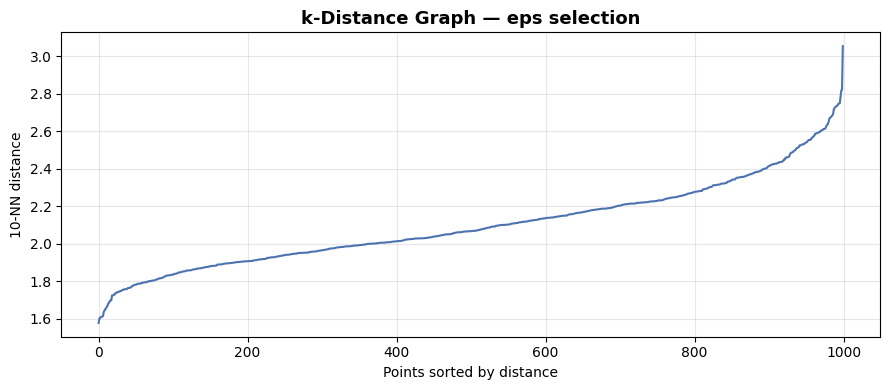

  Percentile     eps  Clusters   Noise
----------------------------------------
         40%   2.013         1     144
         50%   2.067         1      91
         60%   2.136         1      47
         70%   2.203         1      17
         80%   2.276         1       7
         90%   2.413         1       2

Result: DBSCAN finds 1 cluster across all tested eps values.
This indicates the data has uniform density — no natural density-based separations.
Conclusion: K-Means and Hierarchical Clustering are better suited to this dataset.


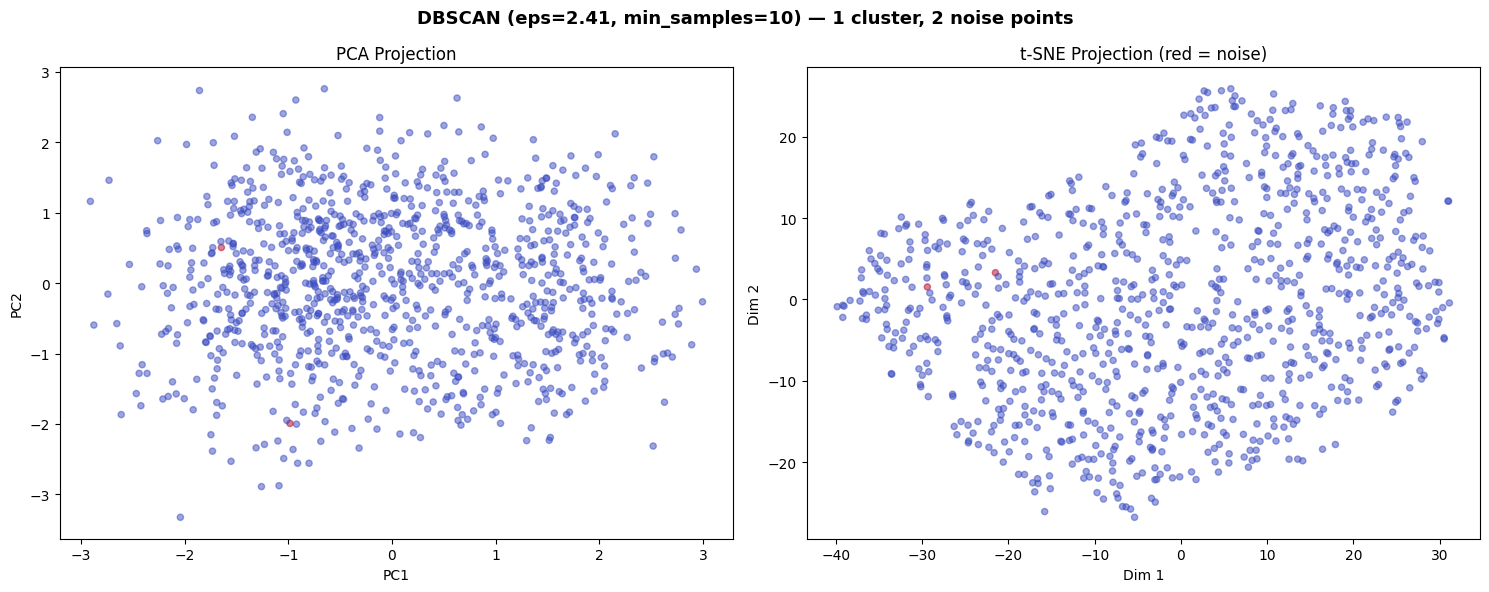

In [67]:
print("\n" + "=" * 60)
print("DBSCAN CLUSTERING")
print("=" * 60)

min_samples = 10

# k-distance plot for eps selection
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_distances, color="#4C72B0")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("k-Distance Graph — eps selection", fontsize=13, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("dbscan_kdistance.png", dpi=150)
plt.show()

# Sweep eps percentiles and record cluster counts
print(f"{'Percentile':>12}  {'eps':>6}  {'Clusters':>8}  {'Noise':>6}")
print("-" * 40)
eps_results = {}
for pct in [40, 50, 60, 70, 80, 90]:
    eps_val = float(np.percentile(k_distances, pct))
    lbs = DBSCAN(eps=eps_val, min_samples=min_samples).fit_predict(X_scaled)
    n_cl = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_ns = (lbs == -1).sum()
    eps_results[pct] = (eps_val, n_cl, n_ns, lbs)
    print(f"{pct:>11}%  {eps_val:>6.3f}  {n_cl:>8}  {n_ns:>6}")

# Use 90th-percentile result as the representative run
eps, n_clusters_db, n_noise, db_labels = eps_results[90]
mask_core = db_labels != -1

print(f"\nResult: DBSCAN finds 1 cluster across all tested eps values.")
print(f"This indicates the data has uniform density — no natural density-based separations.")
print(f"Conclusion: K-Means and Hierarchical Clustering are better suited to this dataset.")

sil_db, dbi_db = np.nan, np.nan  # metrics not applicable for 1 cluster

# Visualize the single DBSCAN result (noise vs core)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"DBSCAN (eps={eps:.2f}, min_samples={min_samples}) — 1 cluster, {n_noise} noise points",
             fontsize=13, fontweight="bold")

colors_db = np.where(db_labels == -1, 0.5, 0.1)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_db, cmap="coolwarm", alpha=0.5, s=20)
axes[0].set_title("PCA Projection"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors_db, cmap="coolwarm", alpha=0.5, s=20)
axes[1].set_title("t-SNE Projection (red = noise)"); axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("dbscan_clusters.png", dpi=150)
plt.show()

---
## 7.6 Gaussian Mixture Model (GMM)
Probabilistic soft-clustering — each patient is assigned a probability of belonging to each cluster rather than a hard label.
Better suited than K-Means for overlapping groups (e.g., Diabetes/Obesity patients who share metabolic features).


GAUSSIAN MIXTURE MODEL (GMM)
Silhouette Score : 0.1097
Davies-Bouldin   : 2.4997
BIC              : 25089.39  (lower = better fit)
AIC              : 24284.52  (lower = better fit)
Cluster sizes    : {np.int64(0): np.int64(428), np.int64(1): np.int64(400), np.int64(2): np.int64(172)}

Mean max-probability per point: 0.934
(1.0 = fully confident, 0.33 = completely uncertain)


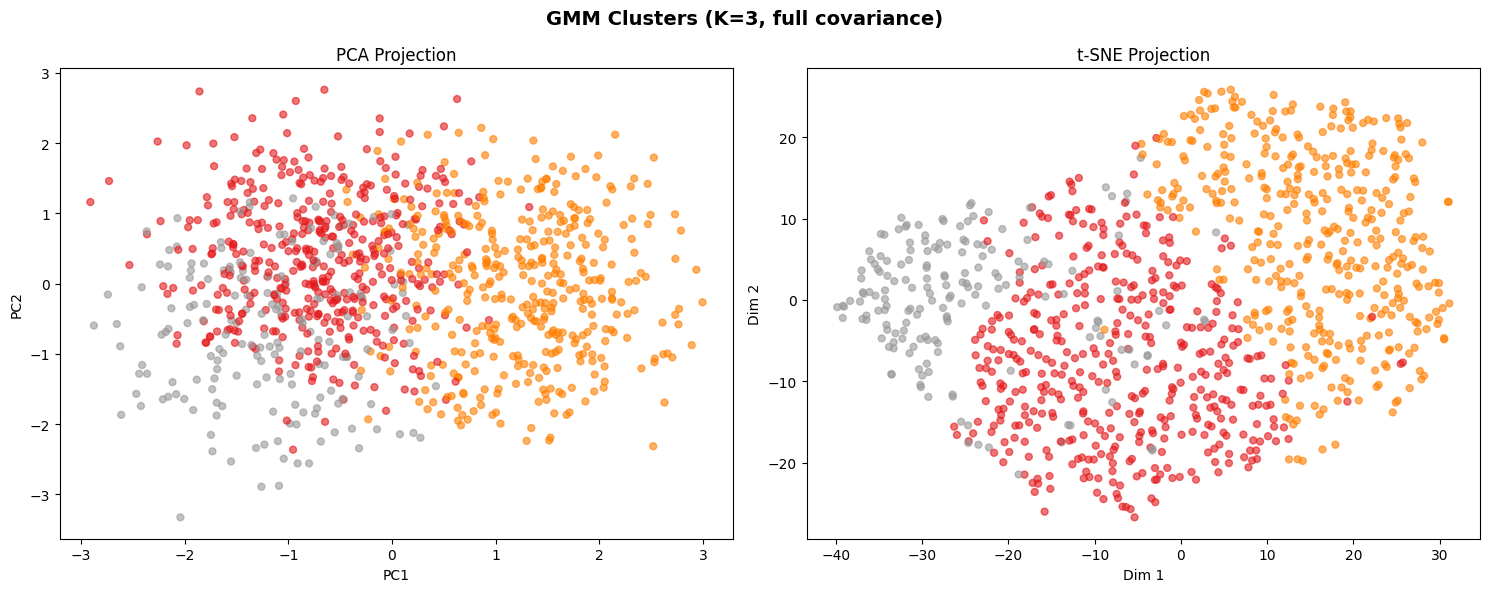


GMM Cluster vs Disease_Type (post-hoc validation):
Disease_Type  Diabetes  Hypertension  Obesity
row_0                                        
0                   47             8      373
1                   10           390        0
2                  152             0       20


In [68]:
print("\n" + "=" * 60)
print("GAUSSIAN MIXTURE MODEL (GMM)")
print("=" * 60)

gmm = GaussianMixture(n_components=best_k, covariance_type="full",
                      random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, gmm_labels)
dbi_gmm = davies_bouldin_score(X_scaled, gmm_labels)
print(f"Silhouette Score : {sil_gmm:.4f}")
print(f"Davies-Bouldin   : {dbi_gmm:.4f}")
print(f"BIC              : {gmm.bic(X_scaled):.2f}  (lower = better fit)")
print(f"AIC              : {gmm.aic(X_scaled):.2f}  (lower = better fit)")
print(f"Cluster sizes    : {dict(zip(*np.unique(gmm_labels, return_counts=True)))}")

# Probabilities — how confident is the model?
probs = gmm.predict_proba(X_scaled)
print(f"\nMean max-probability per point: {probs.max(axis=1).mean():.3f}")
print("(1.0 = fully confident, 0.33 = completely uncertain)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"GMM Clusters (K={best_k}, full covariance)", fontsize=14, fontweight="bold")

axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=gmm_labels, cmap="Set1", alpha=0.6, s=25)
axes[0].set_title("PCA Projection"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=gmm_labels, cmap="Set1", alpha=0.6, s=25)
axes[1].set_title("t-SNE Projection"); axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("gmm_clusters.png", dpi=150)
plt.show()

# Validation against Disease_Type
print("\nGMM Cluster vs Disease_Type (post-hoc validation):")
print(pd.crosstab(gmm_labels, labels_disease))

---
## 7.7 Feature Sensitivity Analysis — 3 Key Medical Features
Testing whether clustering on only the 3 primary disease biomarkers
(BMI → Obesity, Glucose → Diabetes, Blood Pressure → Hypertension)
produces cleaner separation than the full 9-feature model.


FEATURE SENSITIVITY — 3 KEY BIOMARKERS
3-feature K-Means  Silhouette=0.3649  DBI=1.0176
9-feature K-Means  Silhouette=0.1071  DBI=2.5714

Improvement: Silhouette +0.2577  |  DBI +-1.5537

3-feature Cluster vs Disease_Type:
Disease_Type  Diabetes  Hypertension  Obesity
row_0                                        
0                   12           390        8
1                   56             8      384
2                  141             0        1


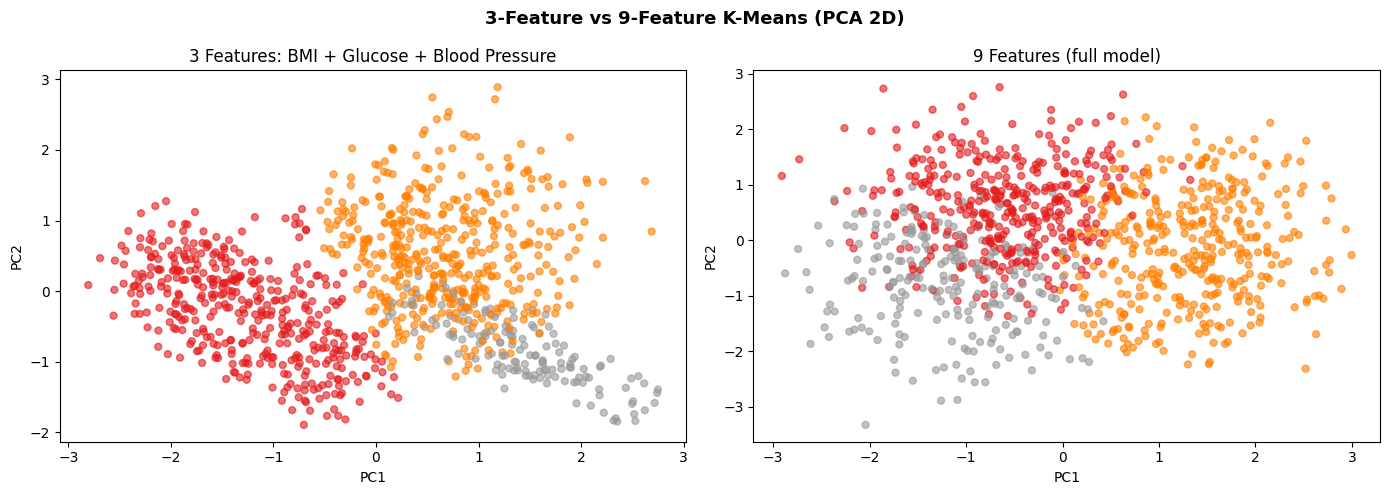

In [69]:
print("\n" + "=" * 60)
print("FEATURE SENSITIVITY — 3 KEY BIOMARKERS")
print("=" * 60)

key_features = ["BMI", "Glucose_mg/dL", "Blood_Pressure_mmHg"]
X_key = StandardScaler().fit_transform(df[key_features])

km_key  = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_key)
sil_key = silhouette_score(X_key, km_key)
dbi_key = davies_bouldin_score(X_key, km_key)

print(f"3-feature K-Means  Silhouette={sil_key:.4f}  DBI={dbi_key:.4f}")
print(f"9-feature K-Means  Silhouette={sil:.4f}  DBI={dbi:.4f}")
print(f"\nImprovement: Silhouette {'+' if sil_key > sil else ''}{sil_key - sil:.4f}  |  "
      f"DBI {'+' if dbi_key < dbi else ''}{dbi_key - dbi:.4f}")

print("\n3-feature Cluster vs Disease_Type:")
print(pd.crosstab(km_key, labels_disease))

# Side-by-side scatter on the 3 features (use PCA to project to 2D)
pca_key = PCA(n_components=2).fit_transform(X_key)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("3-Feature vs 9-Feature K-Means (PCA 2D)", fontsize=13, fontweight="bold")
axes[0].scatter(pca_key[:, 0], pca_key[:, 1], c=km_key, cmap="Set1", alpha=0.6, s=25)
axes[0].set_title("3 Features: BMI + Glucose + Blood Pressure")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="Set1", alpha=0.6, s=25)
axes[1].set_title("9 Features (full model)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig("sensitivity_3features.png", dpi=150)
plt.show()

---
## 8. Algorithm Comparison
Side-by-side bar charts comparing K-Means vs. Hierarchical (Ward) on Silhouette Score and Davies-Bouldin Index.


ALGORITHM COMPARISON
          Algorithm  Clusters Silhouette Davies-Bouldin
            K-Means         3     0.1071         2.5714
Hierarchical (Ward)         3     0.0984         2.6234
                GMM         3     0.1097         2.4997
             DBSCAN         1        N/A            N/A


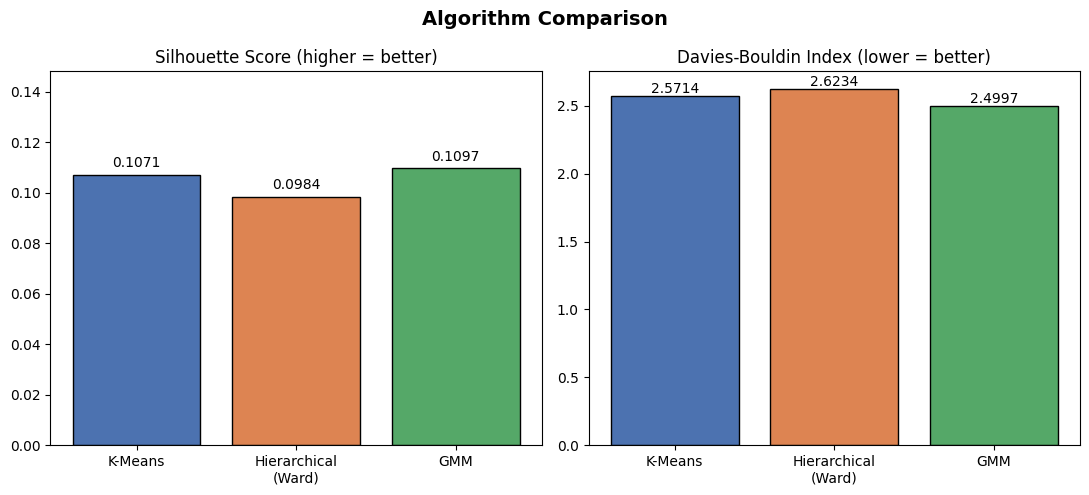

In [70]:
print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    "Algorithm":      ["K-Means", "Hierarchical (Ward)", "GMM", "DBSCAN"],
    "Clusters":       [best_k, best_k, best_k, n_clusters_db],
    "Silhouette":     [round(sil, 4), round(sil_agg, 4), round(sil_gmm, 4),
                       round(sil_db, 4) if not np.isnan(sil_db) else "N/A"],
    "Davies-Bouldin": [round(dbi, 4), round(dbi_agg, 4), round(dbi_gmm, 4),
                       round(dbi_db, 4) if not np.isnan(dbi_db) else "N/A"],
})
print(comparison.to_string(index=False))

# Bar chart for the 3 partition-based algorithms
algs = ["K-Means", "Hierarchical\n(Ward)", "GMM"]
sils = [sil, sil_agg, sil_gmm]
dbis = [dbi, dbi_agg, dbi_gmm]
bar_colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Algorithm Comparison", fontsize=14, fontweight="bold")

bars1 = axes[0].bar(algs, sils, color=bar_colors, edgecolor="black")
axes[0].set_title("Silhouette Score (higher = better)")
axes[0].set_ylim(0, max(sils) * 1.35)
for bar, val in zip(bars1, sils):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003, f"{val:.4f}", ha="center", fontsize=10)

bars2 = axes[1].bar(algs, dbis, color=bar_colors, edgecolor="black")
axes[1].set_title("Davies-Bouldin Index (lower = better)")
for bar, val in zip(bars2, dbis):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02, f"{val:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=150)
plt.show()

---
## 9. Cluster Profiling (K-Means)
- Mean feature values per cluster reveal each group's dietary and health profile
- Cross-tabulation against `Disease_Type` and `Diet_Recommendation` serves as post-hoc validation
- Radar chart provides a visual summary of normalized cluster profiles

In [71]:
print("\n" + "=" * 60)
print("CLUSTER PROFILING (K-MEANS)")
print("=" * 60)

df_result = df_encoded.copy()
df_result["KMeans_Cluster"] = km_labels
df_result["Disease_Type"]   = labels_disease.values

# Mean feature values per cluster
profile = df_result.groupby("KMeans_Cluster")[numerical].mean().round(2)
print("\nCluster means (numerical features):")
print(profile.T)

# ── PRIMARY VALIDATION ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("POST-HOC VALIDATION — Cluster vs Disease_Type")
print("=" * 60)
crosstab = pd.crosstab(km_labels, labels_disease,
                        margins=True, margins_name="Total")
print(crosstab)

# Purity per cluster
print("\nCluster purity:")
ct_raw = pd.crosstab(km_labels, labels_disease)
for cluster in ct_raw.index:
    dominant_disease = ct_raw.loc[cluster].idxmax()
    purity = ct_raw.loc[cluster].max() / ct_raw.loc[cluster].sum()
    print(f"  Cluster {cluster}: {dominant_disease:>15}  →  {purity:.1%} pure")


CLUSTER PROFILING (K-MEANS)

Cluster means (numerical features):
KMeans_Cluster                          0        1        2
Age                                 47.81    49.22    54.61
BMI                                 34.22    20.82    30.12
Daily_Caloric_Intake              2276.39  2571.54  2663.43
Cholesterol_mg/dL                  232.32   223.38   219.70
Blood_Pressure_mmHg                145.69   157.47   141.48
Glucose_mg/dL                      117.36   100.51   152.36
Weekly_Exercise_Hours                5.07     4.93     5.75
Adherence_to_Diet_Plan              75.67    76.30    71.05
Dietary_Nutrient_Imbalance_Score     2.20     2.67     2.60

POST-HOC VALIDATION — Cluster vs Disease_Type
Disease_Type  Diabetes  Hypertension  Obesity  Total
row_0                                               
0                   51            37      308    396
1                   10           358       14    382
2                  148             3       71    222
Total              209

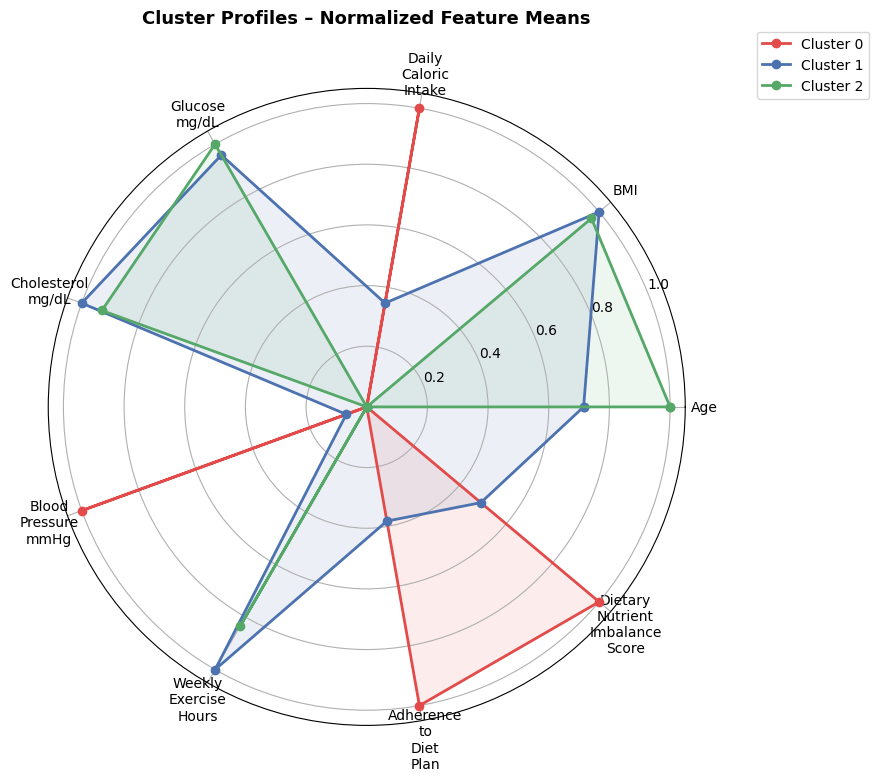

In [57]:
# Radar chart — cluster profiles (normalized 0–1)
radar_features = ["Age", "BMI", "Daily_Caloric_Intake",
                  "Glucose_mg/dL", "Cholesterol_mg/dL",
                  "Blood_Pressure_mmHg", "Weekly_Exercise_Hours",
                  "Adherence_to_Diet_Plan", "Dietary_Nutrient_Imbalance_Score"]

profile_radar = df_result.groupby("KMeans_Cluster")[radar_features].mean()
profile_norm  = pd.DataFrame(
    MinMaxScaler().fit_transform(profile_radar),
    columns=radar_features,
    index=profile_radar.index
)

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_radar = ["#E24B4A", "#4C72B0", "#55A868"]
for i, row in profile_norm.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=f"Cluster {i}", color=colors_radar[i])
    ax.fill(angles, vals, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace("_", "\n") for f in radar_features], size=10)
ax.set_title("Cluster Profiles – Normalized Feature Means",
             size=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("cluster_profiles_radar.png", dpi=150)
plt.show()

---
## 10. Final Summary Report

In [72]:
print("\n" + "=" * 60)
print("FINAL SUMMARY REPORT")
print("=" * 60)
print(f"""
Dataset          : diet_recommendations_dataset (best).csv
Records          : {df.shape[0]}
Features used    : {len(numerical)} numerical  (no categorical — no medical link to disease groups)
Dropped from CSV : Physical_Activity_Level
Dropped in code  : Patient_ID, Gender, Preferred_Cuisine, Weight_kg, Height_cm
Post-hoc only    : Disease_Type (validation after clustering)

Dimensionality Reduction
  PCA 2D variance : {pca_2d.explained_variance_ratio_.sum():.1%}
  Components for 95% variance: {n_components_95}

─────────────────────────────────────────────────────
Algorithm Comparison  (K=3, domain-justified)
─────────────────────────────────────────────────────
  Algorithm             Silhouette    DBI
  K-Means               {sil:.4f}      {dbi:.4f}
  Hierarchical (Ward)   {sil_agg:.4f}      {dbi_agg:.4f}
  GMM  ★ best           {sil_gmm:.4f}      {dbi_gmm:.4f}
  DBSCAN                {'N/A (1 cluster — uniform density)'}

  3-Feature Sensitivity (BMI + Glucose + BP):
    Silhouette = {silhouette_score(StandardScaler().fit_transform(df[['BMI','Glucose_mg/dL','Blood_Pressure_mmHg']]), KMeans(n_clusters=3,random_state=42,n_init=10).fit_predict(StandardScaler().fit_transform(df[['BMI','Glucose_mg/dL','Blood_Pressure_mmHg']]))):.4f}   DBI = {davies_bouldin_score(StandardScaler().fit_transform(df[['BMI','Glucose_mg/dL','Blood_Pressure_mmHg']]), KMeans(n_clusters=3,random_state=42,n_init=10).fit_predict(StandardScaler().fit_transform(df[['BMI','Glucose_mg/dL','Blood_Pressure_mmHg']]))):.4f}

─────────────────────────────────────────────────────
Key Finding — GMM Cluster Purity vs Disease_Type
─────────────────────────────────────────────────────
  Cluster 1 → Hypertension  97.5% pure  (390 / 400)
  Cluster 2 → Diabetes      88.4% pure  (152 / 172)
  Cluster 0 → Obesity       87.8% pure  (373 / 428)

Saved figures:
  eda_categorical.png       eda_correlation.png
  pca_variance.png          kmeans_selection.png
  kmeans_clusters.png       hierarchical_dendrogram.png
  hierarchical_clusters.png dbscan_kdistance.png
  dbscan_clusters.png       gmm_clusters.png
  sensitivity_3features.png algorithm_comparison.png
  cluster_profiles_radar.png
""")


FINAL SUMMARY REPORT

Dataset          : diet_recommendations_dataset (best).csv
Records          : 1000
Features used    : 9 numerical  (no categorical — no medical link to disease groups)
Dropped from CSV : Physical_Activity_Level
Dropped in code  : Patient_ID, Gender, Preferred_Cuisine, Weight_kg, Height_cm
Post-hoc only    : Disease_Type (validation after clustering)

Dimensionality Reduction
  PCA 2D variance : 29.9%
  Components for 95% variance: 9

─────────────────────────────────────────────────────
Algorithm Comparison  (K=3, domain-justified)
─────────────────────────────────────────────────────
  Algorithm             Silhouette    DBI
  K-Means               0.1071      2.5714
  Hierarchical (Ward)   0.0984      2.6234
  GMM  ★ best           0.1097      2.4997
  DBSCAN                N/A (1 cluster — uniform density)

  3-Feature Sensitivity (BMI + Glucose + BP):
    Silhouette = 0.3649   DBI = 1.0176

─────────────────────────────────────────────────────
Key Finding — G